In [14]:
import os
import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pylab as plt
import cv2

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import image_dataset_from_directory

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/animal-image-classification-5-species")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animal-image-classification-5-species' dataset.
Path to dataset files: /kaggle/input/animal-image-classification-5-species


In [16]:
path

'/kaggle/input/animal-image-classification-5-species'

In [17]:
os.listdir(path)

['animals_dataset']

In [18]:
main_path = os.path.join(path, 'animals_dataset')
os.listdir(main_path)

['validation', 'test', 'train']

In [19]:
train = os.path.join(main_path, 'train')
test = os.path.join(main_path, 'test')
val = os.path.join(main_path, 'validation')

In [20]:
os.listdir(train)

['lion', 'dog', 'deep', 'cow', 'cat']

In [21]:
os.listdir(test)

['lion', 'dog', 'deep', 'cow', 'cat']

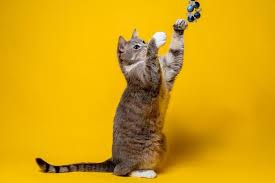

In [22]:
cat0 = os.path.join(os.path.join(train,'cat'),(os.listdir((os.path.join(train, 'cat')))[0]))
Image.open(cat0)

In [23]:
train_ds = image_dataset_from_directory(
    train,
    image_size= (180,180),
    batch_size=32,
    shuffle=True
)

test_ds = image_dataset_from_directory(
    test,
    image_size= (180,180),
    batch_size=32,
    shuffle=True
)

val = image_dataset_from_directory(
    val,
    image_size= (180,180),
    batch_size=32,
    shuffle=True
)

Found 464 files belonging to 5 classes.
Found 82 files belonging to 5 classes.
Found 83 files belonging to 5 classes.


In [24]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
# model = Sequential([
#     data_augmentation,
#     layers.Rescaling(1./255),
#     layers.Conv2D(32, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Conv2D(64, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Conv2D(128, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(5, activation='softmax')
# ])

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

all_callbacks = [

    ModelCheckpoint(
        filepath="Animal_Classification.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min"
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )
]

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 5
# 1. Base Pre-trained Model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pre-trained weights

# 2. Build Pipeline
inputs = tf.keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)  # Scaling
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# Note: Har Output Neurons aap ki total classes ke barabar hone chahiye (e.g., 5 classes)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 3. Lower Learning Rate Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # Ya 'categorical_crossentropy'
    metrics=['accuracy']
)

/tmp/ipykernel_1230/1563743806.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
# Training Execution
history = model.fit(
    train_ds,
    validation_data=val,
    epochs=20,
    callbacks=all_callbacks)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 645ms/step - accuracy: 0.1918 - loss: 2.1950 - val_accuracy: 0.1205 - val_loss: 1.9470
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 523ms/step - accuracy: 0.2392 - loss: 1.9185 - val_accuracy: 0.2410 - val_loss: 1.6882
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 576ms/step - accuracy: 0.2823 - loss: 1.7221 - val_accuracy: 0.4337 - val_loss: 1.4491
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 554ms/step - accuracy: 0.4138 - loss: 1.4553 - val_accuracy: 0.5060 - val_loss: 1.2444
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 600ms/step - accuracy: 0.4289 - loss: 1.3517 - val_accuracy: 0.5904 - val_loss: 1.0652
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 542ms/step - accuracy: 0.5366 - loss: 1.1461 - val_accuracy: 0.7590 - val_loss: 0.9157
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 573ms/step - accuracy: 0.6401 - loss: 0.9924 - val_accuracy: 0.7952 - val_loss: 0.7918
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 610ms/step - accuracy: 0.6961 - loss: 0.9061 - val_accuracy:

In [37]:
model.evaluate(train_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 486ms/step - accuracy: 0.9612 - loss: 0.2594


[0.2593868374824524, 0.9612069129943848]

In [36]:
model.evaluate(test_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 354ms/step - accuracy: 0.9634 - loss: 0.2677


[0.2677100598812103, 0.9634146094322205]

In [38]:
import gradio as gr

In [41]:
import numpy as np
from PIL import Image

# 1. Dataset loading cell se class names extract karein
class_names = train_ds.class_names  # e.g., ['class_a', 'class_b', 'class_c']

def pred_image(image_path):
    # 2. Image load aur preprocess karein
    image = Image.open(image_path).convert("RGB")
    image = image.resize((180, 180))

    # NumPy array setup & Batch Dimension
    arr = np.array(image, dtype=np.float32)
    arr = np.expand_dims(arr, axis=0)  # Shape: (1, 180, 180, 3)

    # 3. Model Prediction (Probabilities array)
    predictions = model.predict(arr, verbose=0)

    # 4. Highest probability wala index aur class label nikalen
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    confidence = float(np.max(predictions[0])) * 100

    return f"Prediction: {predicted_label} ({confidence:.2f}%)"

In [46]:
app = gr.Interface(
    fn=pred_image,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Gun Detection Classifier"
)

In [47]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c25ba94aadb5f062b6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [48]:
train_ds.class_names

['cat', 'cow', 'deep', 'dog', 'lion']